# **Fine-tuning Model with CODA + Siriraj for TB Classification**

## **Import Libraries**

In [27]:
import os
import pandas as pd
import numpy as np
import gc
from pathlib import Path
from typing import List, Dict
import re
import copy
from tqdm.auto import tqdm
import random

# ==== Torch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# ==== Scikit Learn ====
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score, 
    accuracy_score
)

# ==== Visulization ====
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns

# ==== Chroma Vector Database ====
import chromadb
from chromadb.config import Settings

## **Project Setup**

In [2]:
# ==== Check Device ==== 
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(torch.version.cuda)
    print(f"✅ Using CUDA device: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ CUDA not available. Using CPU.")
print(f"Device: {DEVICE}")

12.8
✅ Using CUDA device: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## **Configuration Parameters**

In [3]:
# ==== Path Configurations ====
DB_PATH:str = "../../data/chroma_db"

# ==== Vector Database ====
CODA_DB: str = "coda_vector_db"
SI_DB: str = "old_siriraj_vector_db"
CHROMA_GET_BATCH_SIZE: str = 4096

# ==== Data Splitting ====
n_folds: int = 5
val_size: float = 0.25

# ==== Seed Setting ====
seed: int = 42

# ==== MLP Classification Architecture ====
INPUT_SIZE: int = 512
HIDDEN_SIZE: int = 256 
OUTPUT_SIZE: int = 1
HIDDEN_DIMS: List[int] = [256, 128, 64]
DROPOUT: float = 0.5

# ==== Early Stopping ====
PATIENCE: int = 10
MODE: str = "min"
MONITOR: str = "val_loss"
DELTA: float = 0.001

# ==== Training Loop =========================================

# - Pre-train (CODA) — large dataset, more epochs
PT_EPOCHS       = 30
PT_LR           = 3e-4
PT_BATCH_SIZE   = 16
PT_PATIENCE     = 10

# - Fine-tune (SI) — small dataset, fewer epochs, lower LR
FT_EPOCHS       = 20
FT_LR           = 1e-5    # ← 30x lower than pre-train LR
FT_BATCH_SIZE   = 8
FT_PATIENCE     = 10

# ============================================================

# ==== Optimizer ====
OPTIMIZER: str = "adam"

# ==== Loss Function ====
LOSS_FUNCTION: str = "focal_loss"

print("✅ Configuration loaded.")

✅ Configuration loaded.


### Locked Random Seed

In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Environment
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Random seed set to {seed}")

set_seed(seed)
print("✅ All random seeds locked for reproducibility!")

✅ Random seed set to 42
✅ All random seeds locked for reproducibility!


## **Data Preparation**

### Fetch and Build Dataframe

In [5]:
def fetch_all_from_chroma(collection, batch_size: int = 32) -> dict:
    """Fetch all records in batches to avoid SQLite variable limit."""
    total          = collection.count()
    all_embeddings = []
    all_metadatas  = []
    all_ids        = []

    for offset in tqdm(range(0, total, batch_size), desc=f"Fetching {collection.name}"):
        batch = collection.get(
            include = ["embeddings", "metadatas"],
            limit   = batch_size,
            offset  = offset,
        )
        all_embeddings.extend(batch["embeddings"])
        all_metadatas.extend(batch["metadatas"])
        all_ids.extend(batch["ids"])

    return {
        "embeddings" : np.array(all_embeddings, dtype=np.float32),
        "metadatas"  : all_metadatas,
        "ids"        : all_ids,
    }

In [6]:
chroma_client = chromadb.PersistentClient(path=DB_PATH)

coda_collection = chroma_client.get_collection(name=CODA_DB)
si_collection = chroma_client.get_collection(name=SI_DB)

### Build Dataframe from Database

In [7]:
def build_df_from_db(collection, batch_size: int = 40) -> pd.DataFrame:
    results    = fetch_all_from_chroma(collection, batch_size=batch_size)
    embeddings = results["embeddings"]
    metadatas  = results["metadatas"]
    ids        = results["ids"]

    emb_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]
    emb_df   = pd.DataFrame(embeddings, columns=emb_cols)

    meta_df       = pd.DataFrame(metadatas)
    meta_df["id"] = ids

    # ==== Base columns always present ====
    base_cols = ["id", "file_name", "label", "category"]

    # ==== Optional columns — fill with 'unknown' if missing ====
    if "country" not in meta_df.columns:
        meta_df["country"] = "TH"
    if "participant" not in meta_df.columns:
        meta_df["participant"] = None

    df = pd.concat(
        [meta_df[base_cols + ["country", "participant"]], emb_df],
        axis=1
    )
    df["label"] = df["label"].astype(int)
    return df

#### Siriraj

In [8]:
print("📦 Fetching SI dataset...")
df_si = build_df_from_db(si_collection)

print(f"\n✅ SI Dataset")
print(f"   Shape    : {df_si.shape}")
print(f"   Non-TB   : {(df_si['label'] == 0).sum():,}")
print(f"   TB       : {(df_si['label'] == 1).sum():,}")
df_si.iloc[:, :12].head()

📦 Fetching SI dataset...


Fetching old_siriraj_vector_db:   0%|          | 0/13 [00:00<?, ?it/s]


✅ SI Dataset
   Shape    : (512, 518)
   Non-TB   : 325
   TB       : 187


,id,file_name,label,category,country,participant,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5
0,audio_0,001_02-01.wav,0,Non-TB,TH,None,-1.044960,-0.994985,1.841995,-8.510449,3.532761,-2.059614
1,audio_1,001_02-02.wav,0,Non-TB,TH,None,-1.765482,0.497430,-0.309609,-5.022780,1.755003,-3.526640
2,audio_2,001_02-03.wav,0,Non-TB,TH,None,-1.755122,-0.227196,-0.900034,-4.662507,1.684681,-2.988435
3,audio_3,001_02-04.wav,0,Non-TB,TH,None,-1.185073,-0.686719,-2.149752,-4.081336,2.263366,-3.325819
4,audio_4,001_02-05.wav,0,Non-TB,TH,None,-1.337682,-1.053523,-1.396001,-4.157047,1.785936,-3.015491


#### CODA

In [9]:
df_coda = build_df_from_db(coda_collection, batch_size=4096)

print(f"\n✅ CODA IN (India) — Test Set")
print(f"   Shape    : {df_coda.shape}")
print(f"   Non-TB   : {(df_coda['label'] == 0).sum():,}")
print(f"   TB       : {(df_coda['label'] == 1).sum():,}")

df_coda.head()

Fetching coda_vector_db:   0%|          | 0/175 [00:00<?, ?it/s]


✅ CODA IN (India) — Test Set
   Shape    : (714922, 518)
   Non-TB   : 274,145
   TB       : 440,777


,id,file_name,label,category,country,participant,emb_0,emb_1,emb_2,emb_3,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,coda_0,1646882523350-recording-1.wav,0,Non-TB,MG,CODA_TB_1034,-2.405749,1.507666,1.049924,-8.063454,...,2.226406,2.712188,6.456379,3.799548,9.653807,5.368281,9.061358,8.349137,1.582722,5.292312
1,coda_1,1650122651472-recording-1.wav,1,TB,UG,CODA_TB_0247,-1.615117,0.216108,-0.710410,-5.739150,...,-0.584301,3.686903,5.139785,4.381886,5.371758,3.438827,10.880529,4.876362,5.518026,2.684057
2,coda_2,1644405305147-recording-1.wav,1,TB,MG,CODA_TB_1079,-0.971739,0.673664,0.579995,-8.807016,...,2.620340,4.130687,7.609255,3.566305,8.480738,4.701683,8.958578,6.299600,2.346047,5.091161
3,coda_3,1649620519080-recording-1.wav,1,TB,MG,CODA_TB_0244,-2.616037,2.681008,6.242661,-8.401512,...,4.274400,4.454420,8.248583,7.914845,11.973934,3.449453,9.307265,7.104819,2.389936,2.753666
4,coda_4,1649321856090-recording-1.wav,0,Non-TB,UG,CODA_TB_0644,-2.315710,3.074583,0.333657,-8.941917,...,3.089385,2.222506,3.810425,4.174441,8.141199,4.971159,7.604959,7.339182,4.138732,2.969594


### Build Subject Table

In [10]:
def extract_subject_id(filename):
    """Extracts the subject ID (first 3 digits) from the filename."""
    match = re.match(r"^(\d{3})_", filename)
    if match:
        return match.group(1)
    else:
        # Fallback if pattern doesn't match perfectly
        return filename.split('_')[0]

#### Siriraj

In [11]:
# Add 'subject_id' column
df_si['subject_id'] = df_si['file_name'].apply(extract_subject_id)

print(f"Total samples: {len(df_si)}")
print(f"Unique subjects: {df_si['subject_id'].nunique()}")

Total samples: 512
Unique subjects: 15


#### CODA

In [12]:
# Add 'subject_id' column
df_coda['subject_id'] = df_coda['participant']

print(f"Total samples: {len(df_coda)}")
print(f"Unique participants: {df_coda['subject_id'].nunique():,}")

Total samples: 714922
Unique participants: 565


In [13]:
def build_subject_table(df):
    """Creates a DataFrame with one row per subject and their majority label."""
    # Group by subject_id
    # Get the most frequent label (mode)
    subject_df = (
        df.groupby("subject_id")["label"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={"label": "subject_label"})
    )
    return subject_df

#### Siriraj

In [14]:
subject_table_si = build_subject_table(df_si)

X_si_subj = subject_table_si["subject_id"].values
y_si_subj = subject_table_si["subject_label"].values

print(subject_table_si)
print("="*80)
print(f"\nTotal Unique Subjects: {len(X_si_subj)}")

   subject_id  subject_label
0         001              0
1         002              0
2         003              0
3         004              0
4         005              0
5         006              1
6         007              0
7         008              1
8         009              1
9         011              1
10        012              1
11        013              0
12        014              0
13        015              1
14        016              1

Total Unique Subjects: 15


#### CODA

In [15]:
subject_table_coda = build_subject_table(df_coda)

X_coda_in_subj = subject_table_coda["subject_id"].values
y_coda_in_subj = subject_table_coda["subject_label"].values

print(subject_table_coda.head())
print("="*80)
print(f"\nTotal Unique Subjects: {len(X_coda_in_subj)}")

     subject_id  subject_label
0  CODA_TB_0002              1
1  CODA_TB_0003              0
2  CODA_TB_0008              0
3  CODA_TB_0009              0
4  CODA_TB_0010              0

Total Unique Subjects: 565


### Helper Function

In [16]:
def filter_by_subjects(df: pd.DataFrame, subject_ids) -> pd.DataFrame:
    return df[df["subject_id"].isin(set(subject_ids))].reset_index(drop=True)


def print_detailed_stats(df: pd.DataFrame, subj_ids, split_name: str, total_n: int):
    subset         = df[df["subject_id"].isin(subj_ids)]
    tb_df          = subset[subset["label"] == 1]
    nontb_df       = subset[subset["label"] == 0]
    tb_subjs       = sorted(tb_df["subject_id"].unique().tolist())
    nontb_subjs    = sorted(nontb_df["subject_id"].unique().tolist())
    ratio          = len(subj_ids) / total_n

    print(f"  {split_name.upper():5s} SET : {len(subj_ids):>2} subjects ({ratio:.2%})")
    print(f"   ├─ TB    (1) : {len(tb_df):>4} segments | IDs: {', '.join(tb_subjs)}")
    print(f"   └─ NonTB (0) : {len(nontb_df):>4} segments | IDs: {', '.join(nontb_subjs)}")

## **Stratified K Fold for Splitting Data**

In [17]:
def build_cv_folds(
    df_si       : pd.DataFrame,   # SI         — Fine tuning(Train/Val) and Test source
    df_coda     : pd.DataFrame,   # CODA India — Train/Val source
    n_folds     : int   = 5,
    val_size    : float = 0.25,
    random_seed : int   = 42,
) -> dict:

    # ==== CODA subject table (for train/val splits) ====
    subject_table_coda = build_subject_table(df_coda)
    X_coda_subj  = subject_table_coda["subject_id"].values
    y_coda_subj  = subject_table_coda["subject_label"].values
    n_coda_total = len(X_coda_subj)

    # ==== SI subject table (for rotating test splits) ====
    subject_table_si = build_subject_table(df_si)
    X_si_subj  = subject_table_si["subject_id"].values
    y_si_subj  = subject_table_si["subject_label"].values
    n_si_total = len(X_si_subj)

    print(f"\n{'='*80}")
    print(f"  Building {n_folds}-fold combined splits  (CODA for Train/Val · SI test)")
    print(f"{'='*80}")
    print(f"  CODA subjects : {n_coda_total}  | clips: {len(df_coda):,}")
    print(f"  SI subjects   : {n_si_total}     | clips: {len(df_si):,}")

    # ==== SKF on CODA subjects (train/val) ====
    coda_skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)

    # ==== SKF on SI subjects (rotating test) ====
    si_skf      = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)

    all_folds   = []
    coda_splits = list(coda_skf.split(X_coda_subj, y_coda_subj))
    si_splits   = list(si_skf.split(X_si_subj, y_si_subj))

    for fold_idx, (
        (coda_trainval_idx, _),   # ← outer fold gives us 80% CODA for train+val
        (si_ft_idx,     si_test_idx)         # ← outer fold gives us 20% SI for test
    ) in enumerate(zip(coda_splits, si_splits), start=1):

        # ===========================================================
        # CODA: use the 60% trainval portion → split into train/val 
        # ===========================================================
        coda_tv_subj = X_coda_subj[coda_trainval_idx]
        y_tv         = y_coda_subj[coda_trainval_idx]

        inner = StratifiedShuffleSplit(
            n_splits=1,
            test_size=val_size,              # 0.25 of 80% = 20% overall
            random_state=random_seed + fold_idx   # ← different seed per fold
        )
        inner_train_idx, inner_val_idx = next(inner.split(coda_tv_subj, y_tv))

        train_subj = coda_tv_subj[inner_train_idx]   # ~60% of all CODA subjects
        val_subj   = coda_tv_subj[inner_val_idx]     # ~20% of all CODA subjects

        # ======================================================================
        # SI: use the 80% Fine-tuning Train(60%)/Val(20%) and 20% test portion 
        # ======================================================================
        si_ft_subj = X_si_subj[si_ft_idx]
        y_ft_subj  = y_si_subj[si_ft_idx]    

        ft_inner = StratifiedShuffleSplit(
            n_splits=1,
            test_size=val_size,              # 0.25 of 80% = 20% overall
            random_state=random_seed + fold_idx   # ← different seed per fold
        )

        ft_train_idx, ft_val_idx = next(ft_inner.split(si_ft_subj, y_ft_subj))
        ft_train_subj = si_ft_subj[ft_train_idx]   # ~60% of SI subjects for fine-tuning train
        ft_val_subj   = si_ft_subj[ft_val_idx]     # ~20% of SI subjects for fine-tuning

        si_test_subj = X_si_subj[si_test_idx]        # ~20% of SI subjects

        # ==== Leakage checks ====
        assert set(train_subj).isdisjoint(set(val_subj)),      f"Fold {fold_idx}: CODA train/val overlap!"
        # Note: CODA and SI have completely different subject IDs so cross-dataset
        # leakage is impossible, but we check anyway for safety
        assert set(train_subj).isdisjoint(set(si_test_subj)),  f"Fold {fold_idx}: train/SI-test overlap!"
        assert set(val_subj).isdisjoint(set(si_test_subj)),    f"Fold {fold_idx}: val/SI-test overlap!"
        assert set(ft_train_subj).isdisjoint(set(si_test_subj)), f"Fold {fold_idx}: SI fine-tune train/SI-test overlap!"
        assert set(ft_val_subj).isdisjoint(set(si_test_subj)),   f"Fold {fold_idx}: SI fine-tune val/SI-test overlap!"

        # ==== Filter DataFrames ====
        train_df = filter_by_subjects(df_coda, train_subj)
        val_df   = filter_by_subjects(df_coda, val_subj)
        test_df  = filter_by_subjects(df_si,   si_test_subj)
        ft_train_df = filter_by_subjects(df_si, ft_train_subj)
        ft_val_df   = filter_by_subjects(df_si, ft_val_subj)

        # ==== Stats ====
        tb_train    = (train_df["label"] == 1).sum()
        nontb_train = (train_df["label"] == 0).sum()
        tb_val      = (val_df["label"] == 1).sum()
        nontb_val   = (val_df["label"] == 0).sum()
        tb_ft_train = (ft_train_df["label"] == 1).sum()
        nontb_ft_train = (ft_train_df["label"] == 0).sum()
        tb_ft_val   = (ft_val_df["label"] == 1).sum()
        nontb_ft_val   = (ft_val_df["label"] == 0).sum()
        tb_test     = (test_df["label"] == 1).sum()
        nontb_test  = (test_df["label"] == 0).sum()

        # Ratios based on CLIP counts (not subject counts) to match expected output
        ratio_train = len(train_df) / len(df_coda)
        ratio_val   = len(val_df)   / len(df_coda)
        ratio_test  = len(test_df)  / len(df_si)
        ratio_ft_train = len(ft_train_df) / len(df_si)
        ratio_ft_val   = len(ft_val_df)   / len(df_si)

        print(f"\n── Fold {fold_idx} ──")
        print(f"  Train(CODA)         : {len(train_df):>7,} segments ({ratio_train:.1%})"
              f" | TB: {tb_train:>7,} segments | NonTB: {nontb_train:>7,} segments")
        print(f"  Val(CODA)           : {len(val_df):>7,} segments ({ratio_val:.1%})"
              f" | TB: {tb_val:>7,} segments | NonTB: {nontb_val:>7,} segments")
        print(f"  Fine-tune Train(SI) : {len(ft_train_df):>7,} segments ({ratio_ft_train:.1%})"
              f" | TB: {tb_ft_train:>7,} segments | NonTB: {nontb_ft_train:>7,} segments")
        print(f"  Fine-tune Val(SI)   : {len(ft_val_df):>7,} segments ({ratio_ft_val:.1%})"
              f" | TB: {tb_ft_val:>7,} segments | NonTB: {nontb_ft_val:>7,} segments")
        print(f"  Test(SI)            : {len(test_df):>7,} segments ({ratio_test:.1%})"
              f" | TB: {tb_test:>7,} segments | NonTB: {nontb_test:>7,} segments")

        all_folds.append({
            "fold"       : fold_idx,
            "seed"       : random_seed + fold_idx,
            "train"      : train_df,
            "val"        : val_df,
            "ft_train"   : ft_train_df,
            "ft_val"     : ft_val_df,
            "test"       : test_df,
            "train_subj" : sorted(train_subj.tolist()),
            "val_subj"   : sorted(val_subj.tolist()),
            "test_subj"  : sorted(si_test_subj.tolist()),
        })

    print(f"\n{'='*100}")
    print(f"  ✅ NO SUBJECT LEAKAGE  (CODA train/val disjoint; SI Fine-tune and test is independent)")
    print(f"{'='*100}\n")

    return {
        "subject_table_coda" : subject_table_coda,
        "subject_table_si"   : subject_table_si,
        "folds"              : all_folds,
    }

In [18]:
splits = build_cv_folds(
    df_si, 
    df_coda, 
    n_folds=n_folds, 
    val_size=val_size, 
    random_seed=seed
)


  Building 5-fold combined splits  (CODA for Train/Val · SI test)
  CODA subjects : 565  | clips: 714,922
  SI subjects   : 15     | clips: 512

── Fold 1 ──
  Train(CODA)         : 481,036 segments (67.3%) | TB: 305,688 segments | NonTB: 175,348 segments
  Val(CODA)           : 128,805 segments (18.0%) | TB:  70,002 segments | NonTB:  58,803 segments
  Fine-tune Train(SI) :     258 segments (50.4%) | TB:     125 segments | NonTB:     133 segments
  Fine-tune Val(SI)   :     170 segments (33.2%) | TB:      20 segments | NonTB:     150 segments
  Test(SI)            :      84 segments (16.4%) | TB:      42 segments | NonTB:      42 segments

── Fold 2 ──
  Train(CODA)         : 388,808 segments (54.4%) | TB: 233,521 segments | NonTB: 155,287 segments
  Val(CODA)           : 135,836 segments (19.0%) | TB:  70,447 segments | NonTB:  65,389 segments
  Fine-tune Train(SI) :     252 segments (49.2%) | TB:     149 segments | NonTB:     103 segments
  Fine-tune Val(SI)   :     151 segments (2

## **Embedding Extraction & Fold Data Preparation**

In [19]:
EMB_COLS = [c for c in df_si.columns if c.startswith("emb_")]

def get_fold_XY(fold: dict):
    """Extract all 5 splits as numpy arrays from a fold dict."""
    def to_XY(df):
        X = df[EMB_COLS].values.astype(np.float32)
        y = df["label"].values.astype(int)
        return X, y

    X_train,    y_train    = to_XY(fold["train"])
    X_val,      y_val      = to_XY(fold["val"])
    X_ft_train, y_ft_train = to_XY(fold["ft_train"])
    X_ft_val,   y_ft_val   = to_XY(fold["ft_val"])
    X_test,     y_test     = to_XY(fold["test"])

    return X_train, y_train, X_val, y_val, X_ft_train, y_ft_train, X_ft_val, y_ft_val, X_test, y_test

fold_data = []
# Verify all folds
for fold in splits["folds"]:
    X_train, y_train, X_val, y_val, X_ft_train, y_ft_train, X_ft_val, y_ft_val, X_test, y_test = get_fold_XY(fold)
    fold_data.append(get_fold_XY(fold))
    print(f"Fold {fold['fold']} → "
          f"Train: {X_train.shape} | Val: {X_val.shape} | "
          f"FT-Train: {X_ft_train.shape} | FT-Val: {X_ft_val.shape} | "
          f"Test: {X_test.shape}")

Fold 1 → Train: (481036, 512) | Val: (128805, 512) | FT-Train: (258, 512) | FT-Val: (170, 512) | Test: (84, 512)
Fold 2 → Train: (388808, 512) | Val: (135836, 512) | FT-Train: (252, 512) | FT-Val: (151, 512) | Test: (109, 512)
Fold 3 → Train: (471512, 512) | Val: (112539, 512) | FT-Train: (302, 512) | FT-Val: (70, 512) | Test: (140, 512)
Fold 4 → Train: (433849, 512) | Val: (108607, 512) | FT-Train: (386, 512) | FT-Val: (71, 512) | Test: (55, 512)
Fold 5 → Train: (458825, 512) | Val: (139871, 512) | FT-Train: (278, 512) | FT-Val: (110, 512) | Test: (124, 512)


## **MLP Classification**

In [20]:
class MLPModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()

        self.input_dim    = input_dim
        self.hidden_dims  = hidden_dims
        self.dropout      = dropout

        layers   = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Output layer — single logit for binary classification
        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def get_model_info(self) -> Dict:
        """Return architecture summary."""
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {
            "input_dim"       : self.input_dim,
            "hidden_dims"     : self.hidden_dims,
            "dropout"         : self.dropout,
            "total_params"    : total,
            "trainable_params": trainable,
        }

## **Training MLP Classification Model**

### Early Stopping

In [21]:
class EarlyStopping:
    def __init__(self, patience: int, mode: str , monitor: str, delta: float, verbose: bool = True):
        self.patience      = patience
        self.delta         = delta
        self.verbose       = verbose
        self.mode          = mode
        self.monitor       = monitor
        self.best_val_loss = float("inf")
        self.best_state    = None
        self.bad_epochs    = 0
        self.best_epoch    = 0
        self.early_stop    = False

    def __call__(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        improved = val_loss < (self.best_val_loss - self.delta)
        if improved:
            if self.verbose:
                print(f"  ✅ Val loss improved: {self.best_val_loss:.4f} → {val_loss:.4f}  (epoch {epoch+1})")
            self.best_val_loss = val_loss
            self.best_state    = copy.deepcopy(model.state_dict())
            self.bad_epochs    = 0
            self.best_epoch    = epoch
        else:
            self.bad_epochs += 1
            if self.verbose:
                print(f"  ❌ No improvement in val loss: {val_loss:.4f} (best: {self.best_val_loss:.4f})  [bad epochs: {self.bad_epochs}/{self.patience}]")
            if self.bad_epochs >= self.patience:
                if self.verbose:
                    print(f"  ⏰ Early stopping triggered after {self.bad_epochs} bad epochs.")
                self.early_stop = True
            return self.early_stop
    
    def restore_best_weights(self, model: nn.Module) -> None:
        """Load the best weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            if self.verbose:
                print(f"\n✅ Best weights restored from epoch {self.best_epoch+1} "
                      f"(val loss: {self.best_val_loss:.4f})")

### Training Loop

In [22]:
all_fold_results = []

print("\n" + "="*80)
print(f"  Two-Phase Training: Pre-train (CODA) → Fine-tune (SI)")
print(f"  Device: {DEVICE}")
print("="*80)

for fold in splits["folds"]:
    fold_idx = fold["fold"]

    print(f"\n{'='*80}")
    print(f"  Fold {fold_idx} / {n_folds}")
    print(f"{'='*80}")

    X_train, y_train, X_val, y_val, \
    X_ft_train, y_ft_train, X_ft_val, y_ft_val, \
    X_test, y_test = get_fold_XY(fold)

    # ==== Tensors ====
    def to_tensor(X, y):
        return (torch.FloatTensor(X).to(DEVICE),
                torch.FloatTensor(y).unsqueeze(1).to(DEVICE))

    X_train_t,    y_train_t    = to_tensor(X_train,    y_train)
    X_val_t,      y_val_t      = to_tensor(X_val,      y_val)
    X_ft_train_t, y_ft_train_t = to_tensor(X_ft_train, y_ft_train)
    X_ft_val_t,   y_ft_val_t   = to_tensor(X_ft_val,   y_ft_val)
    X_test_t,     y_test_t     = to_tensor(X_test,     y_test)

    # ==== DataLoaders ====
    pt_train_loader = DataLoader(
        torch.utils.data.TensorDataset(X_train_t, y_train_t),
        batch_size=PT_BATCH_SIZE, shuffle=True, drop_last=True
    )
    pt_val_loader = DataLoader(
        torch.utils.data.TensorDataset(X_val_t, y_val_t),
        batch_size=PT_BATCH_SIZE, shuffle=False
    )
    ft_train_loader = DataLoader(
        torch.utils.data.TensorDataset(X_ft_train_t, y_ft_train_t),
        batch_size=FT_BATCH_SIZE, shuffle=True, drop_last=True
    )
    ft_val_loader = DataLoader(
        torch.utils.data.TensorDataset(X_ft_val_t, y_ft_val_t),
        batch_size=FT_BATCH_SIZE, shuffle=False
    )

    # =============================================
    # PHASE 1 — Pre-train on CODA
    # =============================================
    print(f"\n  ── Phase 1: Pre-train on CODA ({len(X_train):,} samples) ──")

    model     = MLPModel(input_dim=INPUT_SIZE, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=PT_LR)
    pt_es     = EarlyStopping(patience=PT_PATIENCE, mode=MODE, monitor=MONITOR, delta=DELTA, verbose=True)
    pt_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(PT_EPOCHS):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in pt_train_loader:
            optimizer.zero_grad()
            out  = model(X_b)
            loss = F.binary_cross_entropy_with_logits(out, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)
            correct    += ((torch.sigmoid(out) > 0.5).float() == y_b).sum().item()
            total      += y_b.size(0)
        train_loss /= total
        train_acc   = correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in pt_val_loader:
                out  = model(X_b)
                loss = F.binary_cross_entropy_with_logits(out, y_b)
                val_loss += loss.item() * X_b.size(0)
                correct  += ((torch.sigmoid(out) > 0.5).float() == y_b).sum().item()
                total    += y_b.size(0)
        val_loss /= total
        val_acc   = correct / total

        pt_history["train_loss"].append(train_loss)
        pt_history["val_loss"].append(val_loss)
        pt_history["train_acc"].append(train_acc)
        pt_history["val_acc"].append(val_acc)

        print(f"  [PT] Epoch {epoch+1:>3}/{PT_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

        if pt_es(val_loss, model, epoch):
            print(f"  ⏰ Pre-train early stop at epoch {epoch+1}")
            break

    pt_es.restore_best_weights(model)   # ✅ ALWAYS restore — whether stopped early or not
    print(f"  ✅ PT best weights restored from epoch {pt_es.best_epoch + 1} "
          f"(val loss: {pt_es.best_val_loss:.4f})")

    # =============================================
    # PHASE 2 — Fine-tune on SI
    # =============================================
    print(f"\n  ── Phase 2: Fine-tune on SI ({len(X_ft_train)} samples) ──")

    ft_optimizer = torch.optim.Adam(model.parameters(), lr=FT_LR)
    ft_es        = EarlyStopping(patience=FT_PATIENCE, mode=MODE, monitor=MONITOR, delta=DELTA, verbose=True)
    ft_history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(FT_EPOCHS):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in ft_train_loader:
            ft_optimizer.zero_grad()
            out  = model(X_b)
            loss = F.binary_cross_entropy_with_logits(out, y_b)
            loss.backward()
            ft_optimizer.step()
            train_loss += loss.item() * X_b.size(0)
            correct    += ((torch.sigmoid(out) > 0.5).float() == y_b).sum().item()
            total      += y_b.size(0)
        train_loss /= total
        train_acc   = correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in ft_val_loader:
                out  = model(X_b)
                loss = F.binary_cross_entropy_with_logits(out, y_b)
                val_loss += loss.item() * X_b.size(0)
                correct  += ((torch.sigmoid(out) > 0.5).float() == y_b).sum().item()
                total    += y_b.size(0)
        val_loss /= total
        val_acc   = correct / total

        ft_history["train_loss"].append(train_loss)
        ft_history["val_loss"].append(val_loss)
        ft_history["train_acc"].append(train_acc)
        ft_history["val_acc"].append(val_acc)

        print(f"  [FT] Epoch {epoch+1:>3}/{FT_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

        if ft_es(val_loss, model, epoch):
            print(f"  ⏰ Fine-tune early stop at epoch {epoch+1}")
            break

    ft_es.restore_best_weights(model)   # ✅ ALWAYS restore — whether stopped early or not
    print(f"  ✅ FT best weights restored from epoch {ft_es.best_epoch + 1} "
          f"(val loss: {ft_es.best_val_loss:.4f})")

    # ==== Store results ====
    fold_data.append((X_train, y_train, X_val, y_val,
                      X_ft_train, y_ft_train, X_ft_val, y_ft_val,
                      X_test, y_test))

    all_fold_results.append({
        "fold"            : fold_idx,
        "model"           : model,           # ✅ now always holds best weights
        "pt_history"      : pt_history,
        "ft_history"      : ft_history,
        "pt_best_epoch"   : pt_es.best_epoch + 1,
        "ft_best_epoch"   : ft_es.best_epoch + 1,
        "pt_best_val_loss": pt_es.best_val_loss,
        "ft_best_val_loss": ft_es.best_val_loss,
        "X_test"          : X_test,
        "y_test"          : y_test,
    })

print("\n✅ Training Complete.")


  Two-Phase Training: Pre-train (CODA) → Fine-tune (SI)
  Device: cuda

  Fold 1 / 5

  ── Phase 1: Pre-train on CODA (481,036 samples) ──
  [PT] Epoch   1/30 | Train Loss: 0.4978 Acc: 0.756 | Val Loss: 0.6557 Acc: 0.644
  ✅ Val loss improved: inf → 0.6557  (epoch 1)
  [PT] Epoch   2/30 | Train Loss: 0.4491 Acc: 0.788 | Val Loss: 0.6909 Acc: 0.651
  ❌ No improvement in val loss: 0.6909 (best: 0.6557)  [bad epochs: 1/10]
  [PT] Epoch   3/30 | Train Loss: 0.4307 Acc: 0.799 | Val Loss: 0.6540 Acc: 0.663
  ✅ Val loss improved: 0.6557 → 0.6540  (epoch 3)
  [PT] Epoch   4/30 | Train Loss: 0.4182 Acc: 0.807 | Val Loss: 0.6769 Acc: 0.664
  ❌ No improvement in val loss: 0.6769 (best: 0.6540)  [bad epochs: 1/10]
  [PT] Epoch   5/30 | Train Loss: 0.4089 Acc: 0.812 | Val Loss: 0.6998 Acc: 0.653
  ❌ No improvement in val loss: 0.6998 (best: 0.6540)  [bad epochs: 2/10]
  [PT] Epoch   6/30 | Train Loss: 0.4030 Acc: 0.815 | Val Loss: 0.6744 Acc: 0.663
  ❌ No improvement in val loss: 0.6744 (best: 0.6

### Visualization of Early Stopping Training per Fold

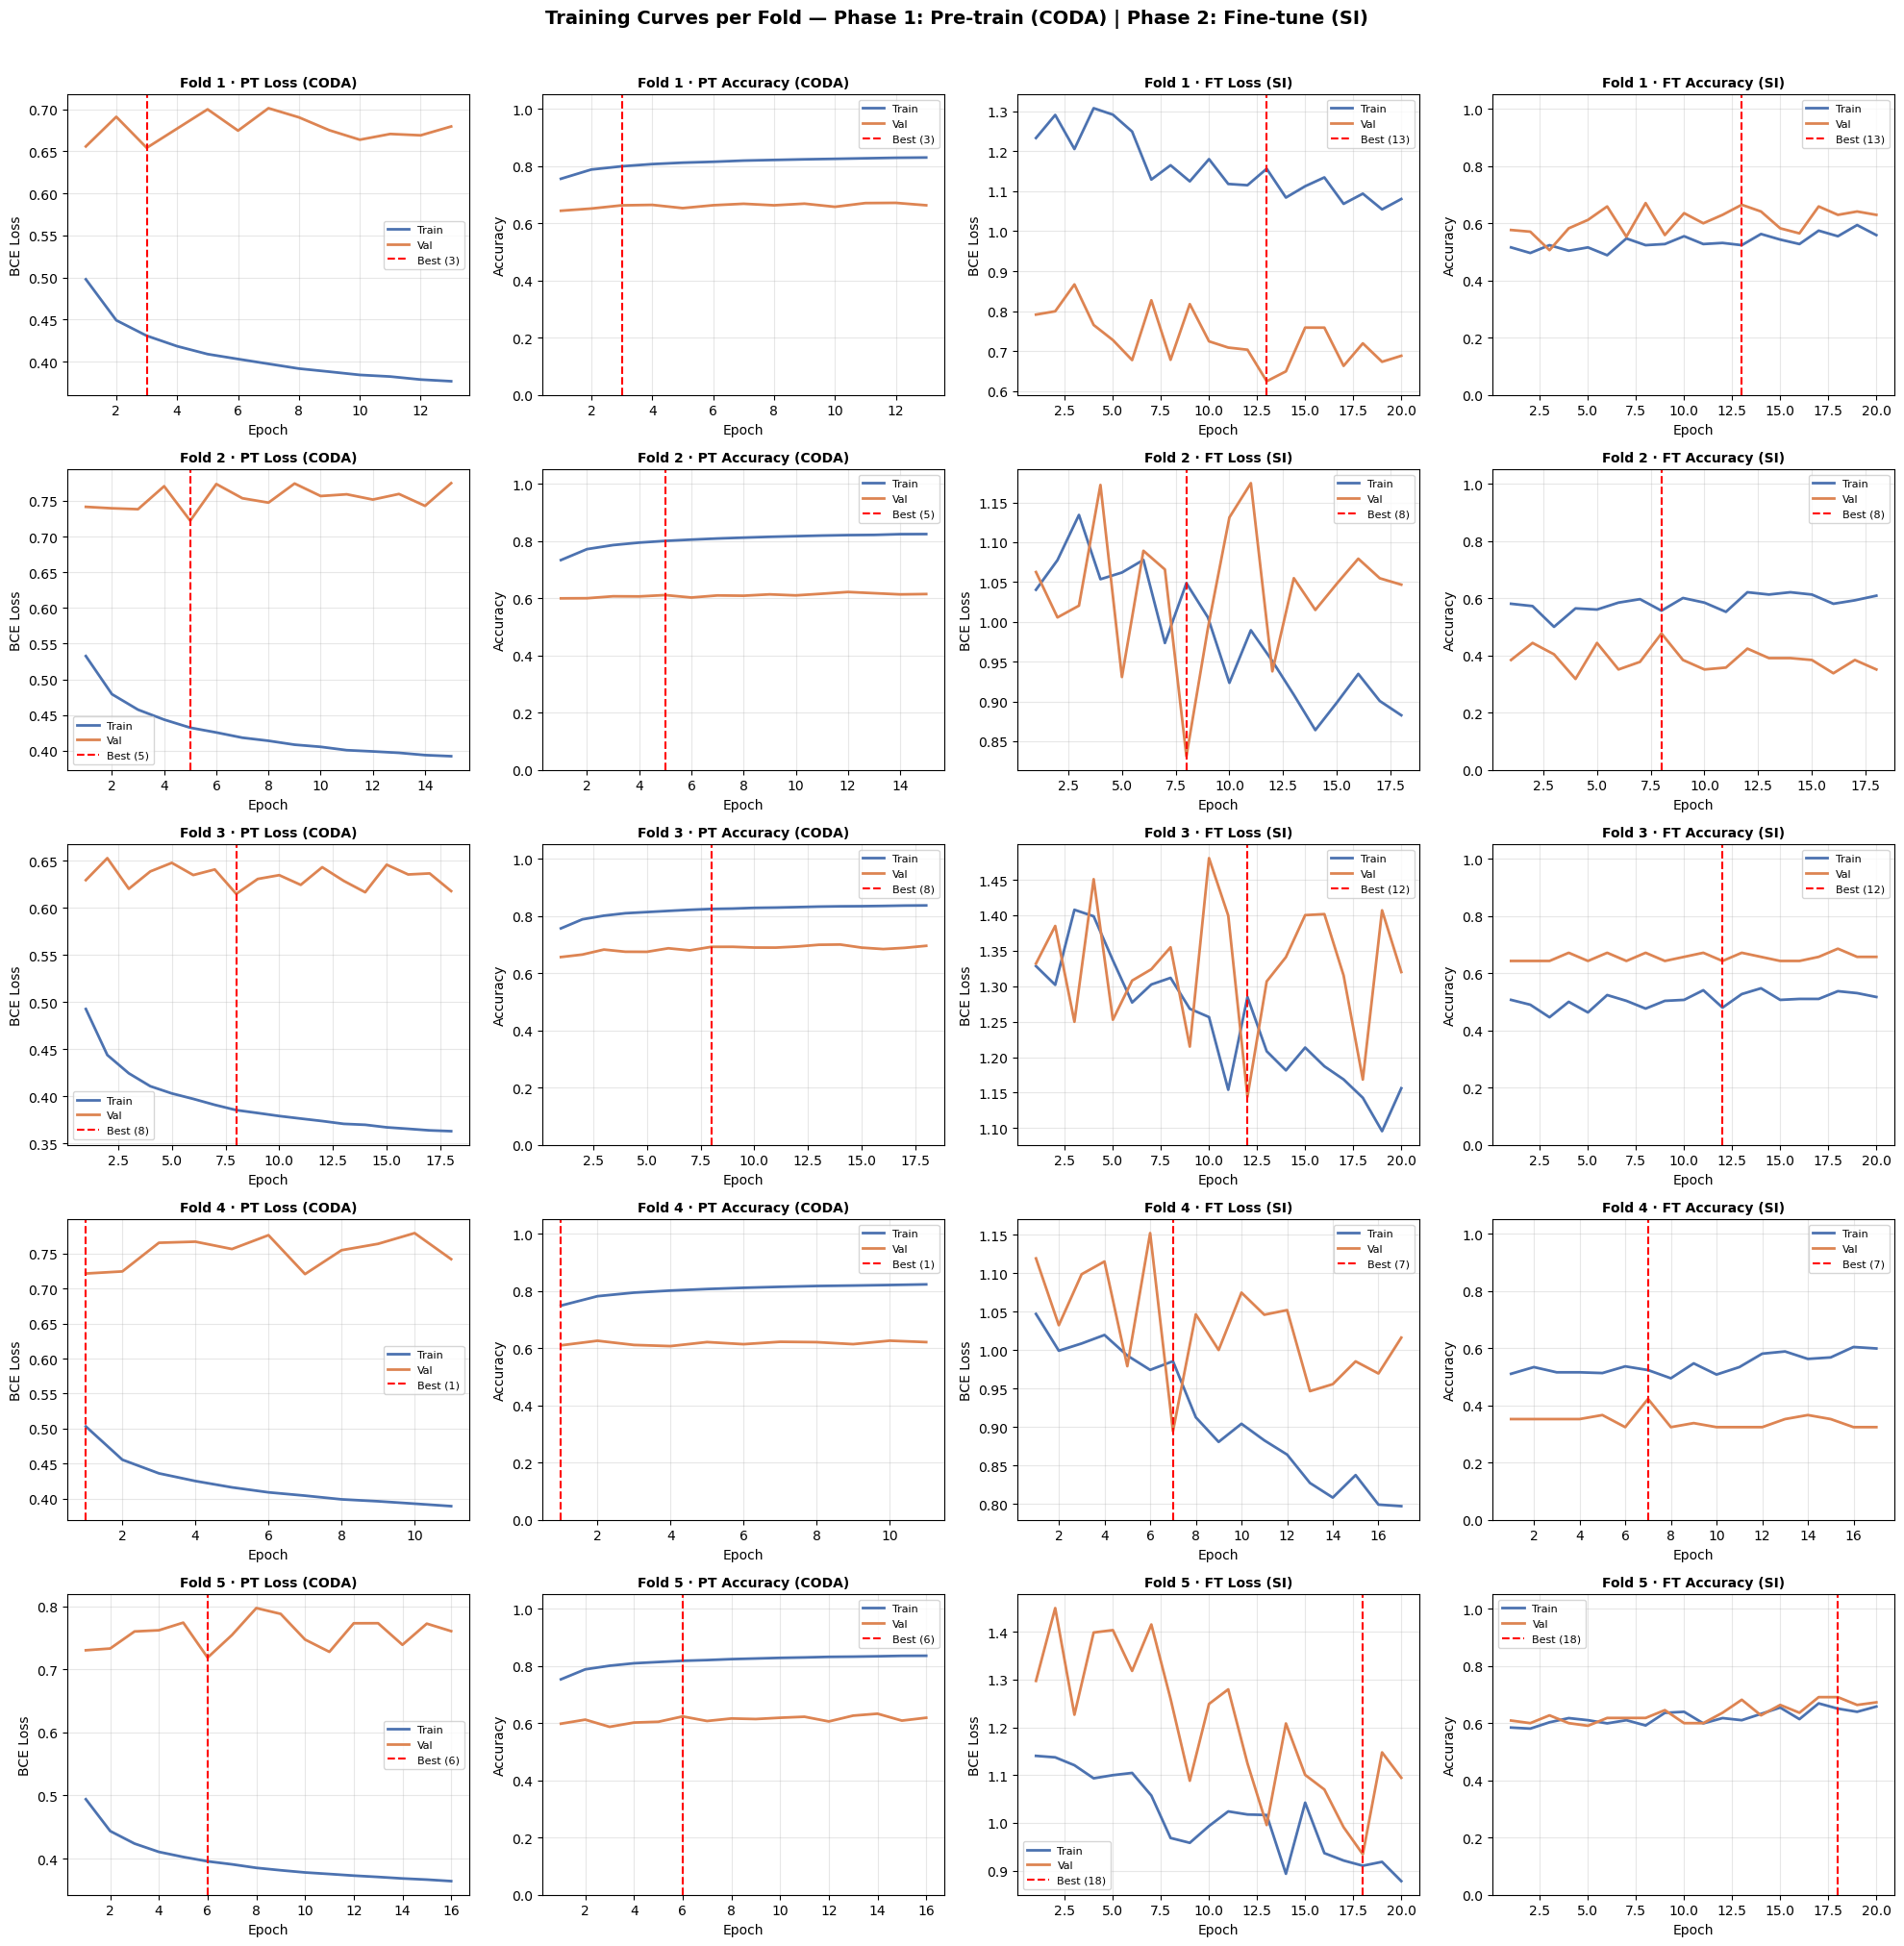

In [23]:
# ============================================================
#   Visualization of Early Stopping Training per Fold
#   Shows Phase 1 (CODA pre-train) + Phase 2 (SI fine-tune)
# ============================================================

fig, axes = plt.subplots(
    nrows   = n_folds,
    ncols   = 4,              # Loss PT | Acc PT | Loss FT | Acc FT
    figsize = (20, 4 * n_folds),
)

fig.suptitle(
    "Training Curves per Fold — Phase 1: Pre-train (CODA) | Phase 2: Fine-tune (SI)",
    fontsize=14, fontweight="bold", y=1.01
)

COLOR_TRAIN = "#4C72B0"
COLOR_VAL   = "#DD8452"
COLOR_BEST  = "red"

for i, result in enumerate(all_fold_results):
    fold_num     = result["fold"]
    pt_history   = result["pt_history"]
    ft_history   = result["ft_history"]
    pt_best      = result["pt_best_epoch"]   # already +1 from training cell
    ft_best      = result["ft_best_epoch"]

    pt_epochs = range(1, len(pt_history["train_loss"]) + 1)
    ft_epochs = range(1, len(ft_history["train_loss"]) + 1)

    # ── Phase 1 Loss ──────────────────────────────────────────
    ax = axes[i, 0]
    ax.plot(pt_epochs, pt_history["train_loss"], label="Train", color=COLOR_TRAIN, lw=2)
    ax.plot(pt_epochs, pt_history["val_loss"],   label="Val",   color=COLOR_VAL,   lw=2)
    ax.axvline(pt_best, color=COLOR_BEST, linestyle="--", lw=1.5, label=f"Best ({pt_best})")
    ax.set_title(f"Fold {fold_num} · PT Loss (CODA)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Phase 1 Accuracy ──────────────────────────────────────
    ax = axes[i, 1]
    ax.plot(pt_epochs, pt_history["train_acc"], label="Train", color=COLOR_TRAIN, lw=2)
    ax.plot(pt_epochs, pt_history["val_acc"],   label="Val",   color=COLOR_VAL,   lw=2)
    ax.axvline(pt_best, color=COLOR_BEST, linestyle="--", lw=1.5, label=f"Best ({pt_best})")
    ax.set_title(f"Fold {fold_num} · PT Accuracy (CODA)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Phase 2 Loss ──────────────────────────────────────────
    ax = axes[i, 2]
    ax.plot(ft_epochs, ft_history["train_loss"], label="Train", color=COLOR_TRAIN, lw=2)
    ax.plot(ft_epochs, ft_history["val_loss"],   label="Val",   color=COLOR_VAL,   lw=2)
    ax.axvline(ft_best, color=COLOR_BEST, linestyle="--", lw=1.5, label=f"Best ({ft_best})")
    ax.set_title(f"Fold {fold_num} · FT Loss (SI)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Phase 2 Accuracy ──────────────────────────────────────
    ax = axes[i, 3]
    ax.plot(ft_epochs, ft_history["train_acc"], label="Train", color=COLOR_TRAIN, lw=2)
    ax.plot(ft_epochs, ft_history["val_acc"],   label="Val",   color=COLOR_VAL,   lw=2)
    ax.axvline(ft_best, color=COLOR_BEST, linestyle="--", lw=1.5, label=f"Best ({ft_best})")
    ax.set_title(f"Fold {fold_num} · FT Accuracy (SI)", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Evaluation Model**

### Evaluation with Classification Report per Fold

In [29]:
fold_probs   = []
fold_y_tests = []

for fold_idx, result in enumerate(all_fold_results):
    model  = result["model"]
    X_test = result["X_test"]       
    y_test = result["y_test"]

    X_test_t = torch.FloatTensor(X_test).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze().cpu().numpy()

    probs = 1 / (1 + np.exp(-logits))
    fold_probs.append(probs)
    fold_y_tests.append(np.asarray(y_test).astype(int))

fold_probs     = np.array(fold_probs, dtype=object)  # ragged — folds have diff test sizes
print(f"✅ Predictions from {len(fold_probs)} folds  "
      f"({sum(len(y) for y in fold_y_tests)} total test samples)")

✅ Predictions from 5 folds  (512 total test samples)


In [31]:
print("\n" + "="*80)
print("SUMMARY OF ALL FOLDS (Per-Fold Test Performance)")
print("="*80 + "\n")

fold_summary = []

for i, (probs, y_true, result) in enumerate(
        zip(fold_probs, fold_y_tests, all_fold_results), start=1):

    fpr, tpr, thresholds = roc_curve(y_true, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thresholds[j_idx])

    preds          = (probs >= thresh).astype(int)
    cm_mat         = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm_mat.ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    acc   = accuracy_score(y_true, preds)
    f1    = f1_score(y_true, preds, zero_division=0) 

    fold_summary.append({
        "Fold"        : i,
        "AUROC"       : f"{auroc:.4f}",
        "AUPRC"       : f"{auprc:.4f}",
        "Sensitivity" : f"{sens:.3f}",
        "Specificity" : f"{spec:.3f}",
        "Threshold"   : f"{thresh:.4f}",
        "PT Best Epoch": result["pt_best_epoch"],   # ✅ pre-train best
        "FT Best Epoch": result["ft_best_epoch"],   # ✅ fine-tune best
        "_auroc": auroc, "_auprc": auprc, "_sens": sens, "_spec": spec, "_acc": acc, "_f1": f1
    })

cols = ["Fold", "AUROC", "AUPRC", "Sensitivity", "Specificity",
        "Threshold", "PT Best Epoch", "FT Best Epoch"]
print(pd.DataFrame(fold_summary)[cols].to_string(index=False))

aurocs = [r["_auroc"] for r in fold_summary]
auprcs = [r["_auprc"] for r in fold_summary]
accs   = [r["_acc"] for r in fold_summary]
f1s    = [r["_f1"] for r in fold_summary]
senss  = [r["_sens"]  for r in fold_summary]
specs  = [r["_spec"]  for r in fold_summary]


print(f"\n{'-'*80}")
print(f"Mean AUROC       : {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")
print(f"Mean AUPRC       : {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")
print(f"Mean Accuracy    : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean F1 Score    : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Mean Sensitivity : {np.mean(senss):.3f} ± {np.std(senss):.3f}")
print(f"Mean Specificity : {np.mean(specs):.3f} ± {np.std(specs):.3f}")
print(f"{'-'*80}")


SUMMARY OF ALL FOLDS (Per-Fold Test Performance)

 Fold  AUROC  AUPRC Sensitivity Specificity Threshold  PT Best Epoch  FT Best Epoch
    1 0.8736 0.8765       0.929       0.714    0.3861              3             13
    2 0.7481 0.4789       0.973       0.639    0.6295              5              8
    3 0.8233 0.4003       0.950       0.650    0.7090              8             12
    4 0.3680 0.1309       0.200       0.960    0.9980              1              7
    5 0.5222 0.7433       0.301       0.902    0.7127              6             18

--------------------------------------------------------------------------------
Mean AUROC       : 0.6670 ± 0.1919
Mean AUPRC       : 0.5260 ± 0.2623
Mean Accuracy    : 0.7315 ± 0.1334
Mean F1 Score    : 0.5463 ± 0.2107
Mean Sensitivity : 0.671 ± 0.345
Mean Specificity : 0.773 ± 0.133
--------------------------------------------------------------------------------


### Visualization of Evaluation with AUROC Curves and Confusion Matrix per Fold

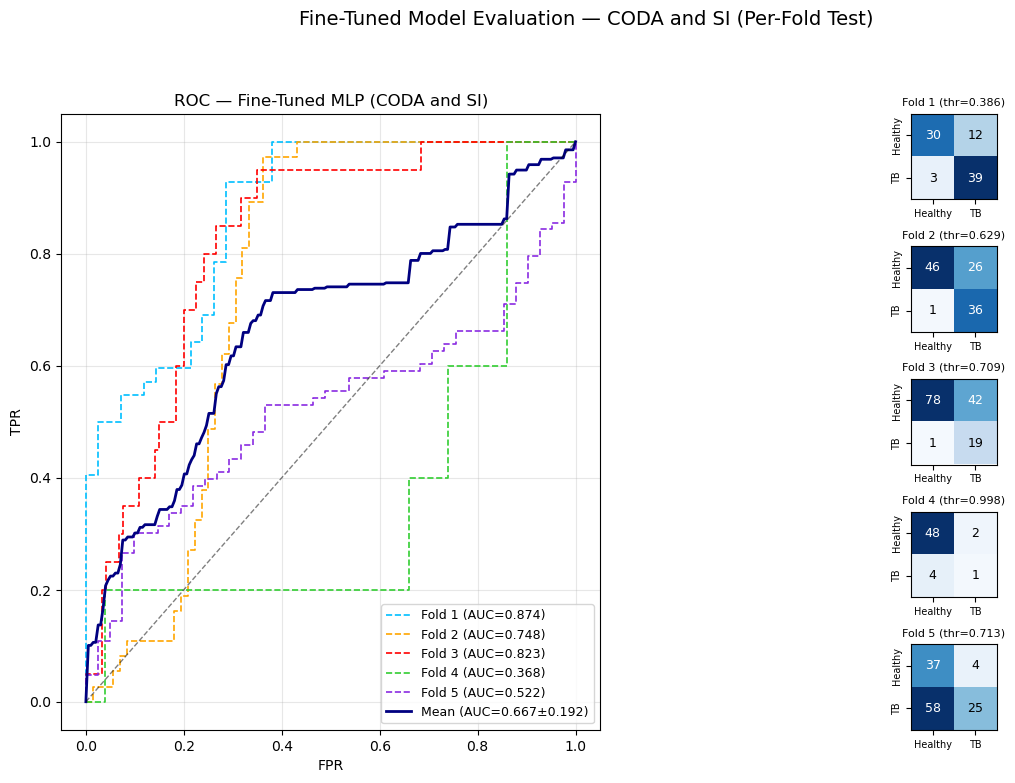

In [26]:
# ── ROC curves + confusion matrices ────────────────────────────────────────────
FOLD_COLORS = ["#00BFFF", "#FFA500", "#FF0000", "#32CD32", "#8A2BE2"]
mean_fpr = np.linspace(0, 1, 200)
fold_fprs, fold_tprs, fold_aucs = [], [], []

for y_true, probs in zip(fold_y_tests, fold_probs):
    fpr, tpr, _ = roc_curve(y_true, probs)
    fold_fprs.append(fpr); fold_tprs.append(tpr); fold_aucs.append(auc(fpr, tpr))

interp_tprs = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fprs, fold_tprs)]
mean_tpr    = np.mean(interp_tprs, axis=0); mean_tpr[0] = 0.0
mean_auc    = auc(mean_fpr, mean_tpr); std_auc = np.std(fold_aucs)      

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.35)

# LEFT: ROC
ax_roc = fig.add_subplot(gs[0])
for i, (fpr, tpr, a) in enumerate(zip(fold_fprs, fold_tprs, fold_aucs)):
    ax_roc.plot(fpr, tpr, color=FOLD_COLORS[i], lw=1.2, ls="--",
                label=f"Fold {i+1} (AUC={a:.3f})")
ax_roc.plot(mean_fpr, mean_tpr, color="navy", lw=2,
            label=f"Mean (AUC={mean_auc:.3f}±{std_auc:.3f})")
ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC — Fine-Tuned MLP (CODA and SI)"); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# RIGHT: Confusion matrices
gs_cm = gridspec.GridSpecFromSubplotSpec(n_folds, 1, subplot_spec=gs[1], hspace=0.55)
for i, (y_true, probs) in enumerate(zip(fold_y_tests, fold_probs)):
    fpr, tpr, ths = roc_curve(y_true, probs)
    thresh = float(ths[np.argmax(tpr - fpr)])
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_true, preds)
    ax = fig.add_subplot(gs_cm[i])
    ax.imshow(cm, cmap=plt.cm.Blues, vmin=0)
    ax.set_title(f"Fold {i+1} (thr={thresh:.3f})", fontsize=8)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Healthy","TB"], fontsize=7)
    ax.set_yticks([0,1]); ax.set_yticklabels(["Healthy","TB"], fontsize=7, rotation=90, va="center")
    mid = cm.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=9,
                    color="white" if cm[r, c] > mid else "black")

plt.suptitle("Fine-Tuned Model Evaluation — CODA and SI (Per-Fold Test)", fontsize=14, y=1.01)
plt.show()